In [26]:
!pip install langgraph langchain langchain-google-genai google-generativeai

In [27]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.tools import tool
from IPython.display import Image



In [28]:
import os
from google.colab import userdata


os.environ["GOOGLE_API_KEY"] = userdata.get("GEMINI_API_KEY")


my_ai_model = ChatGoogleGenerativeAI(
    model='gemini-2.5-flash'
)

## Let's Build a Workflow for New Phone SIM Card Activation & Catching Fraudsters!

### Part 1: Defining What Our SIM Card Application Needs to Know

In [29]:
from typing import TypedDict


class SimApplicationForm(TypedDict):

    applicant_name: str
    id_check_status: str
    doc_check_status: str
    applicant_city: str
    past_sim_requests: int


    id_verification_outcome: str
    fraud_risk_level: str
    final_activation_status: str

### Part 2: Checking IDs and Documents (KYC Node)

In [30]:
@tool
def perform_id_and_doc_check(id_check_status: str, doc_check_status: str) -> str:
    """This tool simulates checking if the applicant's ID and supporting documents are valid."""
    if id_check_status == 'VALID' and doc_check_status == 'VALID':
        return "ALL_GOOD"
    elif id_check_status == 'INVALID' or doc_check_status == 'INVALID':
        return "DOCS_PROBLEM"
    else:
        return "STILL_WAITING_FOR_REVIEW"



def document_check_step(app_state: SimApplicationForm) -> SimApplicationForm:
    check_result = perform_id_and_doc_check.invoke({
        "id_check_status": app_state["id_check_status"],
        "doc_check_status": app_state["doc_check_status"]
    })
    app_state['id_verification_outcome'] = check_result
    return app_state

def fraud_assessment_step(app_state: SimApplicationForm) -> SimApplicationForm:
    # If the documents weren't good, we immediately mark it as high risk, no need to ask the AI.
    if app_state['id_verification_outcome'] != 'ALL_GOOD':
        app_state['fraud_risk_level'] = 'VERY_HIGH_RISK'
        return app_state

    # Otherwise, we ask our smart AI helper to figure out the risk!
    assessment_question = f"""
    Hey AI, can you tell me the fraud risk level for this applicant?
    Please reply with only one of these: LOW_RISK, MEDIUM_RISK, or HIGH_RISK.

    Here's the info:
    Name: {app_state['applicant_name']}
    ID/Doc Check Result: {app_state['id_verification_outcome']}
    City: {app_state['applicant_city']}
    Previous SIMs they asked for: {app_state['past_sim_requests']}

    Some tips for you:
    - If the ID/Doc check failed, it's already considered VERY_HIGH_RISK (we handled that). You don't need to worry about it here.
    - If someone asked for more than 5 SIMs before, or their city looks suspicious, that might be a higher risk.
    - If their ID/Doc check was 'ALL_GOOD', that's a good sign, but still check other things.
    """

    ai_thoughts = my_ai_model.invoke(assessment_question)
    app_state['fraud_risk_level'] = ai_thoughts.content.strip()
    return app_state

In [31]:
def fraud_assessment_step(app_state: SimApplicationForm) -> SimApplicationForm:

    if app_state['id_verification_outcome'] != 'ALL_GOOD':
        app_state['fraud_risk_level'] = 'VERY_HIGH_RISK'
        return app_state


    assessment_question = f"""
    Hey AI, can you tell me the fraud risk level for this applicant?
    Please reply with only one of these: LOW_RISK, MEDIUM_RISK, or HIGH_RISK.

    Here's the info:
    Name: {app_state['applicant_name']}
    ID/Doc Check Result: {app_state['id_verification_outcome']}
    City: {app_state['applicant_city']}
    Previous SIMs they asked for: {app_state['past_sim_requests']}

    Some tips for you:
    - If the ID/Doc check failed, it's already considered VERY_HIGH_RISK (we handled that). You don't need to worry about it here.
    - If someone asked for more than 5 SIMs before, or their city looks suspicious, that might be a higher risk.
    - If their ID/Doc check was 'ALL_GOOD', that's a good sign, but still check other things.
    """

    ai_thoughts = my_ai_model.invoke(assessment_question)
    app_state['fraud_risk_level'] = ai_thoughts.content.strip()
    return app_state

### Part 4: Deciding to Activate the SIM Card (Final Decision Node)

In [32]:
@tool
def make_activation_decision(fraud_risk_level: str) -> str:
    """This tool decides if we activate the SIM, send for manual check, or reject based on risk."""
    if fraud_risk_level == 'LOW_RISK':
        return "SIM Card Activated!"
    elif fraud_risk_level == 'MEDIUM_RISK':
        return "Needs Manual Review"
    else:
        return "Application Rejected"



def final_decision_step(app_state: SimApplicationForm) -> SimApplicationForm:
    the_decision = make_activation_decision.invoke({"fraud_risk_level": app_state['fraud_risk_level']})
    app_state['final_activation_status'] = the_decision
    return app_state

### Part 5: Putting All the Steps Together to Make Our Workflow!

In [33]:
our_sim_workflow_builder = StateGraph(SimApplicationForm)


our_sim_workflow_builder.add_node('document_check', document_check_step)
our_sim_workflow_builder.add_node('fraud_assessment', fraud_assessment_step)
our_sim_workflow_builder.add_node('final_decision', final_decision_step)


our_sim_workflow_builder.set_entry_point('document_check')


our_sim_workflow_builder.add_edge(START, 'document_check')
our_sim_workflow_builder.add_edge('document_check', 'fraud_assessment')
our_sim_workflow_builder.add_edge('fraud_assessment', 'final_decision')
our_sim_workflow_builder.add_edge('final_decision', END)


sim_activation_pipeline = our_sim_workflow_builder.compile()

print("Awesome! Our SIM Card Activation Pipeline is all set!")

Awesome! Our SIM Card Activation Pipeline is all set!


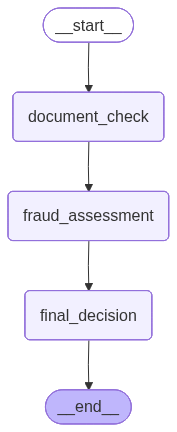

In [34]:
# We can even visualize our workflow if we want to see how the steps connect!
sim_activation_pipeline

### Part 6: Testing Our New SIM Activation Workflow with Different Applicants!

In [35]:
# Test Case 1: A super good applicant!
super_good_applicant: SimApplicationForm = {
    "applicant_name": "Priya",
    "id_check_status": "VALID",
    "doc_check_status": "VALID",
    "applicant_city": "Bengaluru",
    "past_sim_requests": 1,
    "id_verification_outcome": "",
    "fraud_risk_level": "",
    "final_activation_status": ""
}


priya_result = sim_activation_pipeline.invoke(super_good_applicant)
print("Priya's Application Result:", priya_result)

Priya's Application Result: {'applicant_name': 'Priya', 'id_check_status': 'VALID', 'doc_check_status': 'VALID', 'applicant_city': 'Bengaluru', 'past_sim_requests': 1, 'id_verification_outcome': 'ALL_GOOD', 'fraud_risk_level': 'LOW_RISK', 'final_activation_status': 'SIM Card Activated!'}


In [36]:

might_be_risky_applicant: SimApplicationForm = {
    "applicant_name": "Arjun",
    "id_check_status": "VALID",
    "doc_check_status": "VALID",
    "applicant_city": "Mumbai",
    "past_sim_requests": 4,
    "id_verification_outcome": "",
    "fraud_risk_level": "",
    "final_activation_status": ""
}

# Let's see what happens to Arjun's application.
arjun_result = sim_activation_pipeline.invoke(might_be_risky_applicant)
print("Arjun's Application Result:", arjun_result)

Arjun's Application Result: {'applicant_name': 'Arjun', 'id_check_status': 'VALID', 'doc_check_status': 'VALID', 'applicant_city': 'Mumbai', 'past_sim_requests': 4, 'id_verification_outcome': 'ALL_GOOD', 'fraud_risk_level': 'LOW_RISK', 'final_activation_status': 'SIM Card Activated!'}


In [37]:
# Test Case 3: An applicant with bad documents (definite rejection!)
bad_docs_applicant: SimApplicationForm = {
    "applicant_name": "Sneha",
    "id_check_status": "VALID",
    "doc_check_status": "INVALID",
    "applicant_city": "Delhi",
    "past_sim_requests": 0,
    "id_verification_outcome": "",
    "fraud_risk_level": "",
    "final_activation_status": ""
}


sneha_result = sim_activation_pipeline.invoke(bad_docs_applicant)
print("Sneha's Application Result (invalid docs):", sneha_result)

Sneha's Application Result (invalid docs): {'applicant_name': 'Sneha', 'id_check_status': 'VALID', 'doc_check_status': 'INVALID', 'applicant_city': 'Delhi', 'past_sim_requests': 0, 'id_verification_outcome': 'DOCS_PROBLEM', 'fraud_risk_level': 'VERY_HIGH_RISK', 'final_activation_status': 'Application Rejected'}


In [38]:

too_many_sims_applicant: SimApplicationForm = {
    "applicant_name": "Kiran",
    "id_check_status": "VALID",
    "doc_check_status": "VALID",
    "applicant_city": "Chennai",
    "past_sim_requests":
    "id_verification_outcome": "",
    "fraud_risk_level": "",
    "final_activation_status": ""
}


kiran_result = sim_activation_pipeline.invoke(too_many_sims_applicant)
print("Kiran's Application Result (too many SIMs):", kiran_result)

Kiran's Application Result (too many SIMs): {'applicant_name': 'Kiran', 'id_check_status': 'VALID', 'doc_check_status': 'VALID', 'applicant_city': 'Chennai', 'past_sim_requests': 12, 'id_verification_outcome': 'ALL_GOOD', 'fraud_risk_level': 'HIGH_RISK', 'final_activation_status': 'Application Rejected'}


## USE CASE 2: Let's Build a Workflow for Prioritizing Patients in a Hospital!

### Part 1: Defining What Information We Need for Patient Triage

In [39]:
from typing import TypedDict

class PatientInfo(TypedDict):

    body_temp: float
    blood_oxygen: int
    heart_rate: int
    symptom_duration_hours: int
    patient_age: int
    other_illnesses: str


    health_severity_level: str
    appt_priority_level: str
    suggested_care_unit: str

### Part 2: Evaluating How Serious the Symptoms Are (Symptom Check Node)

In [40]:
@tool
def check_symptom_severity(body_temp: float, blood_oxygen: int, heart_rate: int, symptom_duration_hours: int) -> str:
    """This tool looks at patient's numbers and tells us if their condition is STABLE, MODERATE, or CRITICAL."""
    severity_status = "STABLE"


    if body_temp >= 102.0 or blood_oxygen < 90 or heart_rate > 120 or symptom_duration_hours > 48:
        severity_status = "CRITICAL"

    elif body_temp >= 100.4 or blood_oxygen < 94 or heart_rate > 100 or symptom_duration_hours > 24:
        severity_status = "MODERATE"

    return severity_status



def symptom_check_node(current_patient_state: PatientInfo) -> PatientInfo:
    how_serious = check_symptom_severity.invoke({
        "body_temp": current_patient_state["body_temp"],
        "blood_oxygen": current_patient_state["blood_oxygen"],
        "heart_rate": current_patient_state["heart_rate"],
        "symptom_duration_hours": current_patient_state["symptom_duration_hours"]
    })
    current_patient_state['health_severity_level'] = how_serious
    return current_patient_state

### Part 3: Using AI to Decide How Urgent the Appointment Is (Priority Node)

In [41]:
def medical_priority_node(current_patient_state: PatientInfo) -> PatientInfo:

    ai_priority_question = f"""
    Okay AI, based on this patient's info, what kind of appointment priority should they get?
    Just give me one of these options: EMERGENCY, URGENT_CONSULT, or REGULAR_VISIT.
    No extra words, please, just the option!

    Here's what we know about the patient:
    Their health severity: {current_patient_state['health_severity_level']}
    Their age: {current_patient_state['patient_age']}
    Other health problems: {current_patient_state['other_illnesses']}

    Some things to keep in mind:
    - If their health is 'CRITICAL', they definitely need 'EMERGENCY' care.
    - If they're over 60 with 'MODERATE' severity or other serious illnesses, they probably need an 'URGENT_CONSULT'.
    - If they're 'STABLE' and don't have other risk factors, a 'REGULAR_VISIT' is usually fine.
    """

    ai_response_for_priority = my_ai_model.invoke(ai_priority_question)
    current_patient_state['appt_priority_level'] = ai_response_for_priority.content.strip()
    return current_patient_state

### Part 4: Deciding Where to Send the Patient (Care Unit Node)

In [42]:
@tool
def suggest_care_location(appt_priority_level: str) -> str:
    """This tool helps us figure out if the patient should go to the ER, a specialist, or a general doctor."""
    if appt_priority_level == 'EMERGENCY':
        return "ICU/ER"
    elif appt_priority_level == 'URGENT_CONSULT':
        return "Specialist Doctor"
    else:
        return "General Doctor"



def care_assignment_node(current_patient_state: PatientInfo) -> PatientInfo:
    where_to_go = suggest_care_location.invoke({"appt_priority_level": current_patient_state['appt_priority_level']})
    current_patient_state['suggested_care_unit'] = where_to_go
    return current_patient_state

### Part 5: Building Our Patient Triage Workflow!

In [43]:
our_triage_workflow_builder = StateGraph(PatientInfo)

our_triage_workflow_builder.add_node('symptom_check', symptom_check_node)
our_triage_workflow_builder.add_node('medical_priority', medical_priority_node)
our_triage_workflow_builder.add_node('care_assignment', care_assignment_node)


our_triage_workflow_builder.set_entry_point('symptom_check')

our_triage_workflow_builder.add_edge(START, 'symptom_check')
our_triage_workflow_builder.add_edge('symptom_check', 'medical_priority')
our_triage_workflow_builder.add_edge('medical_priority', 'care_assignment')
our_triage_workflow_builder.add_edge('care_assignment', END)


patient_triage_pipeline = our_triage_workflow_builder.compile()

print("Woohoo! Our Healthcare Triage Pipeline is built and ready!")

Woohoo! Our Healthcare Triage Pipeline is built and ready!


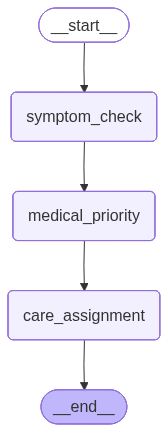

In [44]:

patient_triage_pipeline

### Part 6: Testing Our Patient Triage Workflow with Different Cases!

In [45]:

stable_patient_example: PatientInfo = {
    "body_temp": 97.4,
    "blood_oxygen": 97,
    "heart_rate": 76,
    "symptom_duration_hours": 3,
    "patient_age": 32,
    "other_illnesses": "None",
    "health_severity_level": "",
    "appt_priority_level": "",
    "suggested_care_unit": ""
}


stable_patient_outcome = patient_triage_pipeline.invoke(stable_patient_example)
print("Outcome for the stable patient:", stable_patient_outcome)

Outcome for the stable patient: {'body_temp': 97.4, 'blood_oxygen': 97, 'heart_rate': 76, 'symptom_duration_hours': 3, 'patient_age': 32, 'other_illnesses': 'None', 'health_severity_level': 'STABLE', 'appt_priority_level': 'REGULAR_VISIT', 'suggested_care_unit': 'General Doctor'}


In [46]:

moderate_patient_example: PatientInfo = {
    "body_temp": 101.8,
    "blood_oxygen": 94,
    "heart_rate": 103,
    "symptom_duration_hours": 28,
    "patient_age": 59,
    "other_illnesses": "Diabetes",
    "health_severity_level": "",
    "appt_priority_level": "",
    "suggested_care_unit": ""
}


moderate_patient_outcome = patient_triage_pipeline.invoke(moderate_patient_example)
print("Outcome for the moderate patient:", moderate_patient_outcome)

Outcome for the moderate patient: {'body_temp': 101.8, 'blood_oxygen': 94, 'heart_rate': 103, 'symptom_duration_hours': 28, 'patient_age': 59, 'other_illnesses': 'Diabetes', 'health_severity_level': 'MODERATE', 'appt_priority_level': 'URGENT_CONSULT', 'suggested_care_unit': 'Specialist Doctor'}


In [47]:

critical_patient_example: PatientInfo = {
    "body_temp": 102.5,
    "blood_oxygen": 86,
    "heart_rate": 136,
    "symptom_duration_hours": 55,
    "patient_age": 68,
    "other_illnesses": "Heart Disease",
    "health_severity_level": "",
    "appt_priority_level": "",
    "suggested_care_unit": ""
}


critical_patient_outcome = patient_triage_pipeline.invoke(critical_patient_example)
print("Outcome for the critical patient:", critical_patient_outcome)

Outcome for the critical patient: {'body_temp': 102.5, 'blood_oxygen': 86, 'heart_rate': 136, 'symptom_duration_hours': 55, 'patient_age': 68, 'other_illnesses': 'Heart Disease', 'health_severity_level': 'CRITICAL', 'appt_priority_level': 'EMERGENCY', 'suggested_care_unit': 'ICU/ER'}
